# 02 · CI/CD Compromise Detection with ML

            A held-out comparison of supervised risk classification and benign-only anomaly detection across five synthetic supply-chain scenario families.

## tl;dr

            On **120 held-out synthetic scans**, the random forest reaches **85.1% F1** and **92.5% ROC AUC**. A benign-only Isolation Forest reaches **87.4% F1**. The gap demonstrates why labeled compromise examples help—but these synthetic scores are pipeline validation, not a production benchmark.

## Context & Methods

            We compare two defensible baselines:

            - **Random Forest:** supervised classification using versioned train/test assignments.
            - **Isolation Forest:** anomaly detection fitted only on benign training rows.

            ### Key Assumptions

            - Each row represents one release scan, not an individual package.
            - Features are evidence counts and a bounded blast-radius ratio.
            - The corpus is generated with seed 42; it contains no live incident or customer data.

## Data

Load the checked-in corpus and validate class, family, and split coverage.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if not (ROOT / "pyproject.toml").exists():
    raise RuntimeError("Run this notebook from the repository or a child directory")
sys.path.insert(0, str(ROOT / "src"))

ORANGE = "#f97316"
GOLD = "#f59e0b"
BLUE = "#2563eb"
INK = "#172033"
GRID = "#e5e7eb"
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": INK,
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "font.size": 11,
})

In [2]:
FEATURES = ['critical_count', 'high_count', 'medium_count', 'low_count', 'provenance_failures', 'workflow_exposures', 'vulnerable_components', 'blast_ratio']
frame = pd.read_csv(ROOT / 'data' / 'synthetic_scans.csv')
frame.head()

,scan_id,family,split,critical_count,high_count,medium_count,low_count,provenance_failures,workflow_exposures,vulnerable_components,blast_ratio,compromised
0,SYN-0001,trusted_release,test,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.14831,0
1,SYN-0002,dependency_takeover,train,0.0,3.0,3.0,0.0,0.0,0.0,1.0,0.41398,0
2,SYN-0003,workflow_compromise,train,0.0,3.0,4.0,0.0,0.0,6.0,1.0,0.68566,1
3,SYN-0004,tampered_provenance,train,1.0,3.0,1.0,0.0,3.0,0.0,1.0,0.55111,1
4,SYN-0005,noisy_review,test,0.0,1.0,3.0,4.0,1.0,0.0,2.0,0.35268,1


In [3]:
coverage = frame.groupby(["split", "family", "compromised"]).size().rename("rows").reset_index()
assert set(frame["split"]) == {"train", "test"}
assert frame[FEATURES].notna().all().all()
print(f"Rows: {len(frame)} | Train: {(frame['split'] == 'train').sum()} | Test: {(frame['split'] == 'test').sum()}")
coverage.head(12)

Rows: 480 | Train: 360 | Test: 120


,split,family,compromised,rows
0,test,dependency_takeover,0,8
1,test,dependency_takeover,1,16
2,test,noisy_review,0,13
3,test,noisy_review,1,11
4,test,tampered_provenance,0,1
5,test,tampered_provenance,1,23
6,test,trusted_release,0,24
7,test,workflow_compromise,0,4
8,test,workflow_compromise,1,20
9,train,dependency_takeover,0,24


## Results

Fit both baselines without allowing test rows to influence training.

In [4]:
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay, PrecisionRecallDisplay, accuracy_score, f1_score,
    precision_score, recall_score, roc_auc_score,
)

train = frame[frame["split"] == "train"].copy()
test = frame[frame["split"] == "test"].copy()

classifier = RandomForestClassifier(
    n_estimators=260, max_depth=6, min_samples_leaf=3,
    class_weight="balanced", random_state=42,
)
classifier.fit(train[FEATURES], train["compromised"])
rf_probability = classifier.predict_proba(test[FEATURES])[:, 1]
rf_prediction = (rf_probability >= 0.5).astype(int)

detector = IsolationForest(n_estimators=220, contamination=0.12, random_state=42)
detector.fit(train.loc[train["compromised"] == 0, FEATURES])
iso_prediction = (detector.predict(test[FEATURES]) == -1).astype(int)

metrics = pd.DataFrame([
    {
        "model": "Random Forest",
        "precision": precision_score(test["compromised"], rf_prediction, zero_division=0),
        "recall": recall_score(test["compromised"], rf_prediction, zero_division=0),
        "f1": f1_score(test["compromised"], rf_prediction, zero_division=0),
        "roc_auc": roc_auc_score(test["compromised"], rf_probability),
    },
    {
        "model": "Isolation Forest",
        "precision": precision_score(test["compromised"], iso_prediction, zero_division=0),
        "recall": recall_score(test["compromised"], iso_prediction, zero_division=0),
        "f1": f1_score(test["compromised"], iso_prediction, zero_division=0),
        "roc_auc": np.nan,
    },
]).set_index("model")
metrics.style.format("{:.1%}")

,precision,recall,f1,roc_auc
model,,,,
Random Forest,89.1%,81.4%,85.1%,92.5%
Isolation Forest,90.8%,84.3%,87.4%,nan%


<notebook>:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


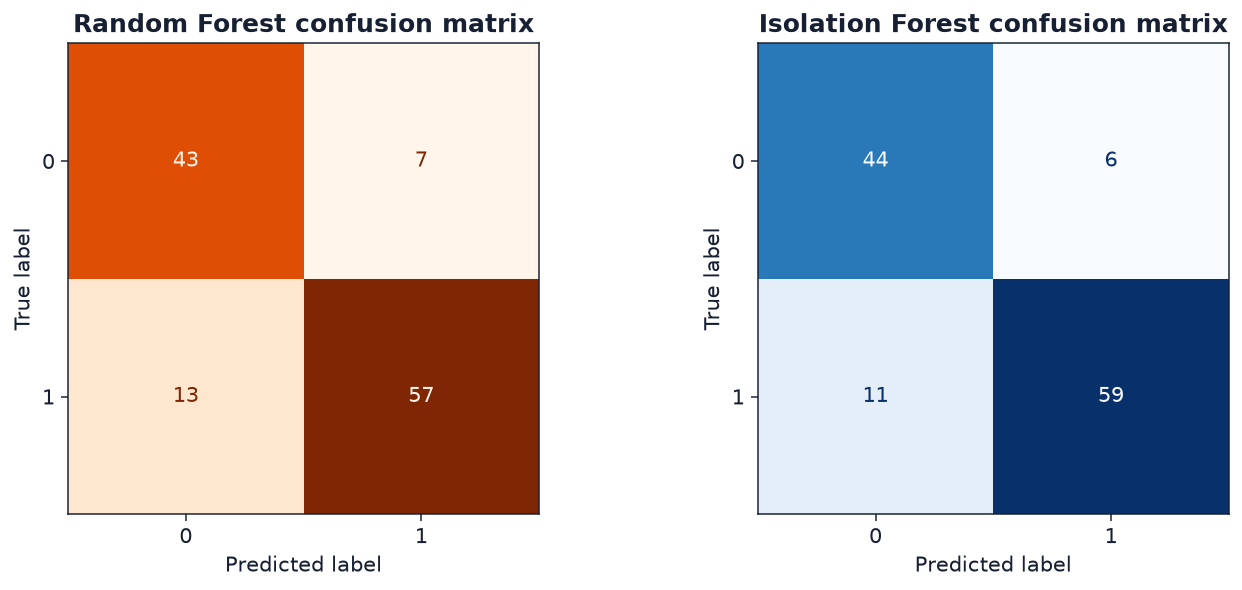

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))
ConfusionMatrixDisplay.from_predictions(test["compromised"], rf_prediction, ax=axes[0], colorbar=False, cmap="Oranges")
ConfusionMatrixDisplay.from_predictions(test["compromised"], iso_prediction, ax=axes[1], colorbar=False, cmap="Blues")
axes[0].set_title("Random Forest confusion matrix", fontweight="bold")
axes[1].set_title("Isolation Forest confusion matrix", fontweight="bold")
plt.tight_layout()
plt.show()

<notebook>:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


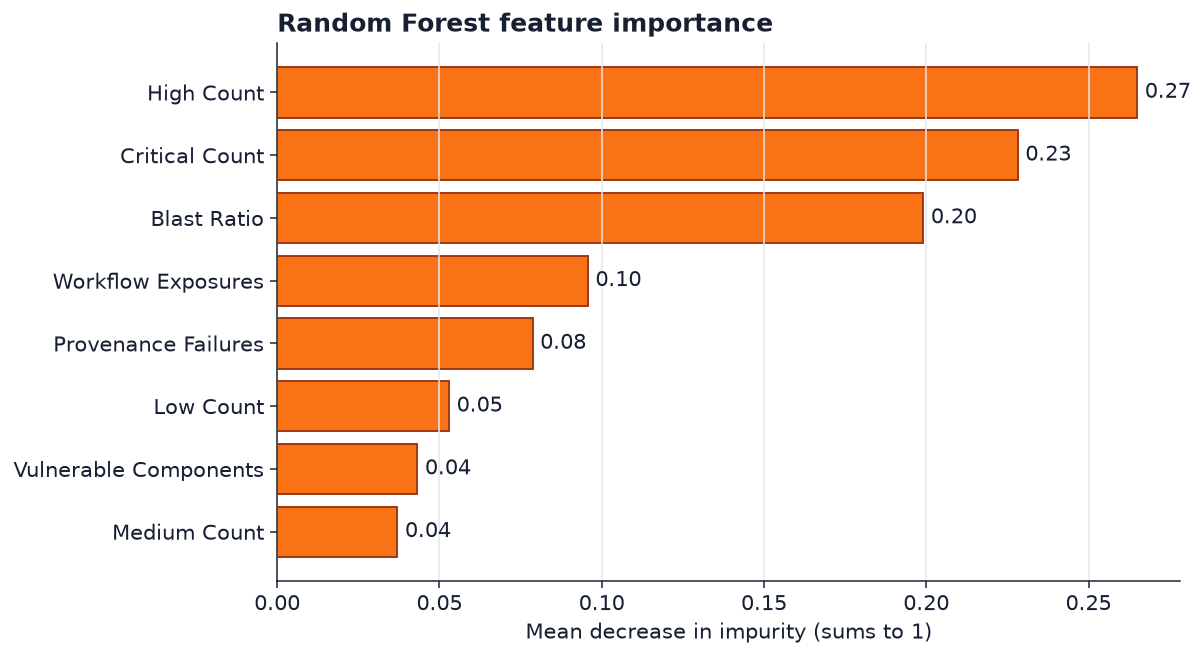

In [6]:
importance = pd.Series(classifier.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(importance.index.str.replace("_", " ").str.title(), importance, color=ORANGE, edgecolor="#9a3412")
ax.bar_label(bars, labels=[f"{value:.2f}" for value in importance], padding=4)
ax.set_title("Random Forest feature importance", loc="left", fontweight="bold")
ax.set_xlabel("Mean decrease in impurity (sums to 1)")
ax.grid(axis="x", color=GRID)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

/Users/vinaysheelkapgate/Documents/Codex/2026-08-12/can/work/cybersecurity-analytics/.venv/lib/python3.12/site-packages/sklearn/utils/_plotting.py:193: FutureWarning: `**kwargs` is deprecated and will be removed in 1.11. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
<notebook>:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


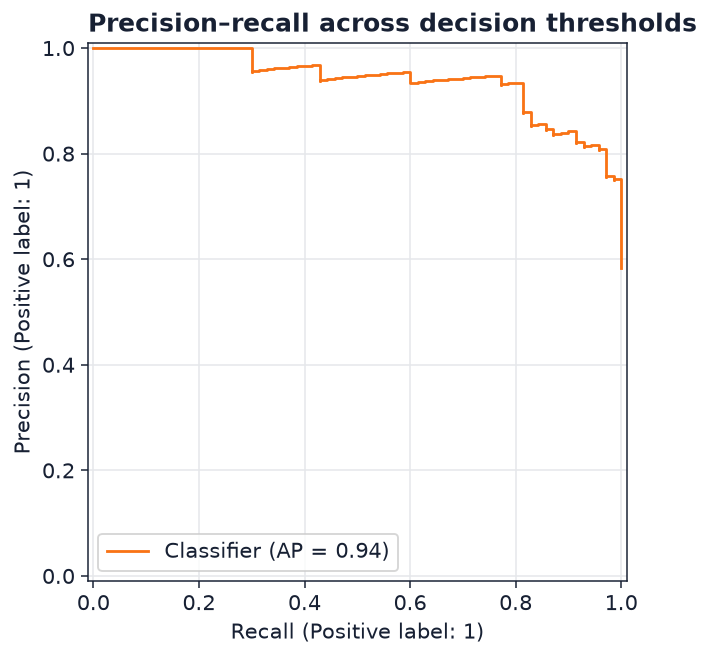

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 5))
PrecisionRecallDisplay.from_predictions(test["compromised"], rf_probability, ax=ax, color=ORANGE)
ax.set_title("Precision–recall across decision thresholds", loc="left", fontweight="bold")
ax.grid(color=GRID)
plt.tight_layout()
plt.show()

## Takeaways

            1. The supervised model achieves **89.1% precision** and **81.4% recall** on the fixed held-out split.
            2. The benign-only detector reaches **84.3% recall** but has a different error profile, making it useful as a secondary signal rather than the sole release gate.
            3. Production evaluation needs time-based splits, real false-positive review, package-ecosystem drift tests, and calibrated thresholds.